# 04 — Model Evaluation
**Visual analysis of XGBoost performance on weather-only features**

Three evaluations:
1. Actual vs Predicted scatter plot
2. Feature importance
3. Error distribution


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
%matplotlib inline
sns.set_style("whitegrid")

# Load data and preprocess
df = pd.read_csv("../data/delhi_ncr_aqi_dataset.csv")
df = df.drop(columns=['datetime','date','station','latitude','longitude'])

day_map    = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
season_map = {'monsoon':0,'summer':1,'post_monsoon':2,'winter':3}
df['day_of_week'] = df['day_of_week'].map(day_map)
df['season']      = df['season'].map(season_map)
df['city']        = LabelEncoder().fit_transform(df['city'])

weather_features = ['year','month','day','hour',
                    'day_of_week','is_weekend','season','city',
                    'temperature','humidity','wind_speed','visibility']

X = df[weather_features]
y = df['aqi']
_, X_te, _, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = joblib.load("../models/best_model_xgboost.pkl")
preds = model.predict(X_te)

mae = mean_absolute_error(y_te, preds)
r2  = r2_score(y_te, preds)
print(f"Test MAE: {mae:.2f}  |  Test R²: {r2:.4f}")

Test MAE: 20.05  |  Test R²: 0.9740


## 1. Actual vs Predicted
Points should cluster tightly around the red diagonal (perfect prediction line).
Scatter away from the line = prediction error.


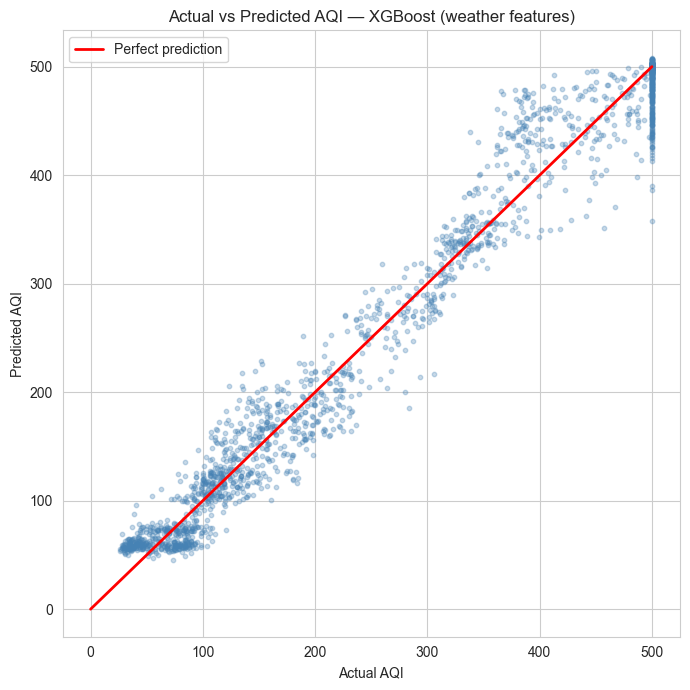

In [2]:
idx    = np.random.choice(len(y_te), 2000, replace=False)
actual = y_te.values[idx]
pred   = preds[idx]

plt.figure(figsize=(7,7))
plt.scatter(actual, pred, alpha=0.3, color='steelblue', s=10)
plt.plot([0,500],[0,500], color='red', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual AQI"); plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI — XGBoost (weather features)")
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150)
plt.show()

**Observation:** Strong alignment along the diagonal from 0–350.
Model consistently underpredicts extreme values (400–500) — these spikes
are caused by events like Diwali or crop burning that weather data alone can't capture.


## 2. Feature importance
Which of the 12 weather features does XGBoost rely on most?


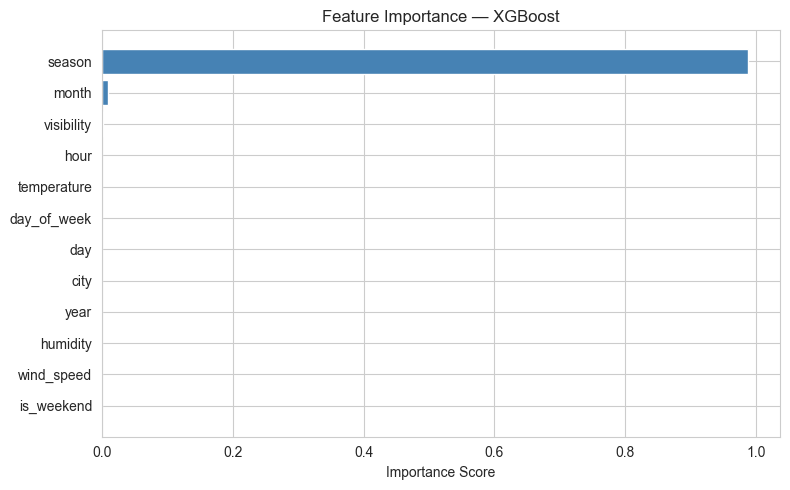

In [3]:
importance = model.feature_importances_
sorted_idx = np.argsort(importance)

plt.figure(figsize=(8,5))
plt.barh([weather_features[i] for i in sorted_idx],
         [importance[i] for i in sorted_idx],
         color='steelblue', edgecolor='white')
plt.xlabel("Importance Score")
plt.title("Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

**Observation:** `season` dominates with near-total importance.
This makes sense given how we encoded it (0=cleanest → 3=most polluted) —
it directly captures Delhi's pollution cycle.
This also reveals a limitation: the model heavily relies on one feature.
Future work could explore removing season encoding to force the model to learn subtler patterns.


## 3. Error distribution
How large are the prediction errors and are they symmetric?


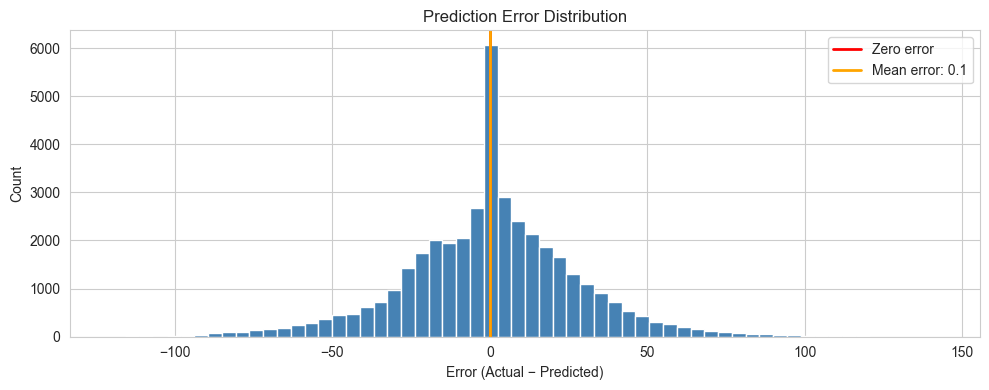

Mean error:   0.10 (near zero = no systematic bias)
50% of errors fall between -15 and 15 AQI points


In [4]:
errors = y_te.values - preds

plt.figure(figsize=(10,4))
plt.hist(errors, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linewidth=2, label='Zero error')
plt.axvline(errors.mean(), color='orange', linewidth=2,
            label=f'Mean error: {errors.mean():.1f}')
plt.xlabel("Error (Actual − Predicted)")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/error_distribution.png', dpi=150)
plt.show()

print(f"Mean error:   {errors.mean():.2f} (near zero = no systematic bias)")
print(f"50% of errors fall between {np.percentile(errors,25):.0f} and {np.percentile(errors,75):.0f} AQI points")

**Observation:** Errors are centred at ~0 with mean error of 0.1 — no systematic over or
underprediction. The slight right tail confirms occasional underprediction on severe days.


## Summary

| Metric | Value |
|--------|-------|
| Algorithm | XGBoost |
| Features | 12 (weather + time only) |
| Test R² | 0.9740 |
| Test MAE | 20.05 AQI points |
| Strongest feature | Season |
| Main limitation | Underpredicts AQI > 400 |

The model explains 97.4% of AQI variation using only weather and temporal features,
with an average error of 20 AQI points on unseen data.
